In [1]:
import os
import numpy as np
import glob
import xarray as xr
import museval
from museval.utils import get_response, find_response, aia_synthesis, wavelength_in_cube
from muse.synthesis.synthesis import transform_resp_units
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import re
from pathlib import Path
from astropy.time import Time
from museval.io import create_session, is_complete, extract_remote_str, files_to_retry
import sunpy.map
import sunpy.visualization.colormaps as cm
import eispac
import astropy.units as u
from astropy.coordinates import SkyCoord
from aiapy.psf import deconvolve, psf
from tqdm import tqdm

In [2]:
## QS VDEM synthesis
os.environ['VDEM_path'] = '/Users/souvikb/MUSE_outputs/vdems/'
vdem_file = os.path.join(os.environ['VDEM_path'], 'muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr')
qs_vdem = xr.open_zarr(vdem_file)
os.environ['RESPONSE'] = '/Users/souvikb/MUSE_outputs/response/new_response/'
work_dir = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/'
# date_sensitive = True
units = 'DN'
channels = [131,171,193,211] # for the Synthetic AIA channels
os.environ['aia_npz_data'] = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/'
str_prefix_npz = 'QS_AIA_'
aia_data_npz = sorted(glob.glob(os.environ['aia_npz_data'] + str_prefix_npz + '*.npz'))


for idx, file in tqdm(enumerate(sorted(aia_data_npz))):
    s = file
    stem = Path(s).stem # gives the filename without directory path and without the final extension
    m = re.search(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", stem) # scans stem for a datetime pattern like YYYY-MM-DDTHH:MM:SS
    dt_str = m.group(0) if m else None

    ## Begin the Response function and AIA synthesis section 
    date = Time(dt_str,format='isot',scale='utc') # astropy time object
    print(f' Date Sensitive AIA {units} Response from {date.strftime("%b %y")}')
    aia_resp = get_response(qs_vdem, date = date, save_response = True) # creating AIA response functions on the fly
    muse_AIA_QS = aia_synthesis(aia_resp, work_dir, vdem_file, swap_dims = False) # Synthesizing AIA QS data from VDEM
    


0it [00:00, ?it/s]

 Date Sensitive AIA DN Response from Apr 14
2026-03-20 16:48:20.671 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 0 months from obs_date 
2026-03-20 16:48:20.672 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Apr14.zarr already exists! Reading...
2026-03-20 16:48:20.820 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-03-20 16:48:20.820 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-03-20 16:48:20.820 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


1it [00:00,  2.55it/s]

 Date Sensitive AIA DN Response from Mar 16
2026-03-20 16:48:21.060 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 7 months from obs_date 
2026-03-20 16:48:21.060 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Aug15.zarr already exists! Reading...
2026-03-20 16:48:21.076 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-03-20 16:48:21.076 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-03-20 16:48:21.077 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


2it [00:00,  3.26it/s]

...

3it [00:00,  3.49it/s]

 Date Sensitive AIA DN Response from Aug 19
2026-03-20 16:48:21.568 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 7 months from obs_date 
2026-03-20 16:48:21.569 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Jan19.zarr already exists! Reading...
2026-03-20 16:48:21.584 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-03-20 16:48:21.584 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-03-20 16:48:21.584 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


4it [00:01,  3.56it/s]

 Date Sensitive AIA DN Response from Dec 19
2026-03-20 16:48:21.841 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 11 months from obs_date 
2026-03-20 16:48:21.842 | INFO     | museval.utils:get_response:170 - *** /Users/souvikb/MUSE_outputs/response/new_response/aia_resp_DN_Jan19.zarr already exists! Reading...
2026-03-20 16:48:21.857 | INFO     | museval.utils:get_response:176 - The channels of the response function match.
2026-03-20 16:48:21.857 | INFO     | museval.utils:aia_synthesis:396 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-03-20 16:48:21.857 | INFO     | museval.utils:aia_synthesis:403 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


5it [00:01,  3.46it/s]


In [3]:
scale_sim = (muse_AIA_QS.flux.y[1]-muse_AIA_QS.flux.y[0])*1e-2*1e-3

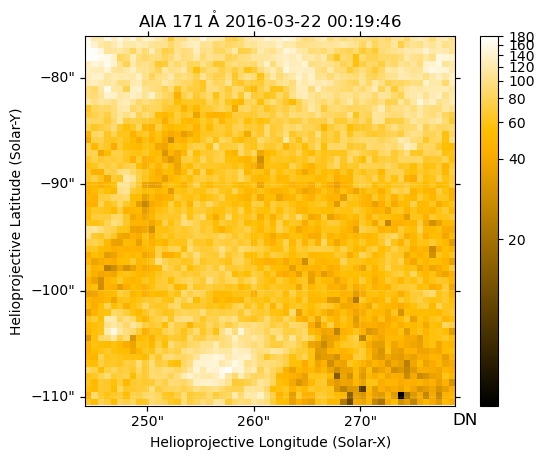

In [4]:
test_dpath = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/SDO_EIS_cutouts_2016-03-22T00:18:40'+'/bigger_sdo_cutouts/'
test_cut_out_map = sunpy.map.Map(test_dpath + 'aia.lev1_euv_12s.2016-03-22T001947Z.171.image_lev1.fits')
test_cut_out_map.peek()

In [6]:
from scipy.ndimage import zoom ## Zoom from scipy does all and more than congrid in IDL
data_sim = muse_AIA_QS.flux.sel(channel=171).squeeze().data
aia_scale_x = test_cut_out_map.scale[0].value*722 #km
aia_scale_y = test_cut_out_map.scale[1].value*722 #km
resampled= zoom(data_sim,
                zoom=(scale_sim.item()/aia_scale_x, scale_sim.item()/aia_scale_y),
                order=3, #order = 3 Cubic spline interpolation
                mode='nearest') # for edges


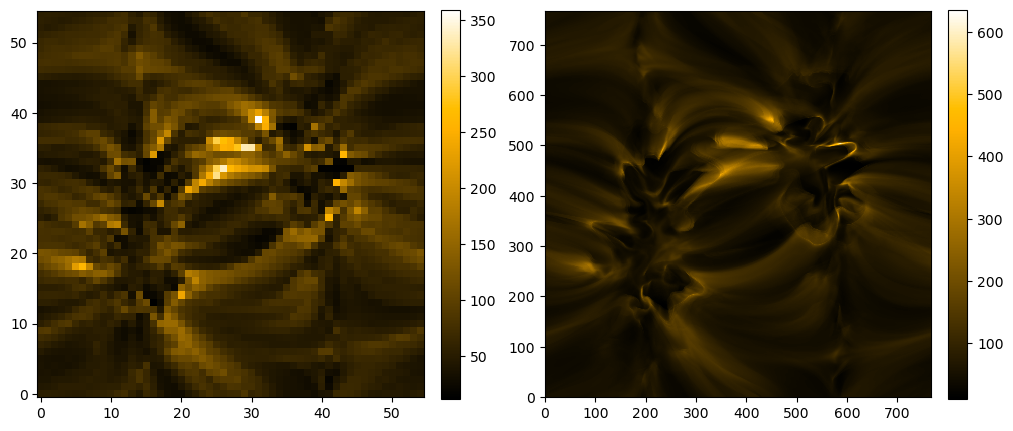

In [7]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12,6))
ax = ax.ravel()
im = ax[0].imshow(resampled,origin='lower', interpolation='none',cmap='sdoaia171')
plt.colorbar(im, ax=ax[0],fraction=0.046, pad=0.04)

im1 = ax[1].imshow(data_sim, origin='lower', interpolation='none',cmap='sdoaia171')
plt.colorbar(im1, ax=ax[1],fraction=0.046, pad=0.04)